<a href="https://colab.research.google.com/github/edumabagraham/uropatch-data-analysis/blob/real_world_implementation/TabPfn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# install tabpfn
!pip install tabpfn

In [5]:
import os
import pickle
# import mlflow
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
# import scikit_posthocs as sp
import matplotlib.pyplot as plt

from tqdm import tqdm
from numpy import sort
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
# from mlflow.models.signature import infer_signature
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier, plot_importance, XGBRFClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import friedmanchisquare
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import torch
# from aeon.visualisation import plot_critical_difference


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
features = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MPhil_Thesis/Phase I/Data/improved_features_data_main/two_class_raw_5s_yo_0.8.csv')

features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
# features.columns

In [9]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

# Split the data into training and testing sets
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder
from tabpfn import TabPFNClassifier
import torch

# 1. Encode labels (if needed)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Train TabPFN
classifier = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu')
classifier.fit(X_train, y_train_encoded)

# 3. Predict
y_pred_encoded = classifier.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)  # Convert back to original labels



tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

=== Classification Report ===
              precision    recall  f1-score   support

    non-void       0.67      0.92      0.77       364
        void       0.73      0.32      0.45       246

    accuracy                           0.68       610
   macro avg       0.70      0.62      0.61       610
weighted avg       0.69      0.68      0.64       610


=== Key Metrics ===
Accuracy: 0.6787
Precision (macro avg): 0.6994
Recall (macro avg): 0.6207
F1-Score (macro avg): 0.6100


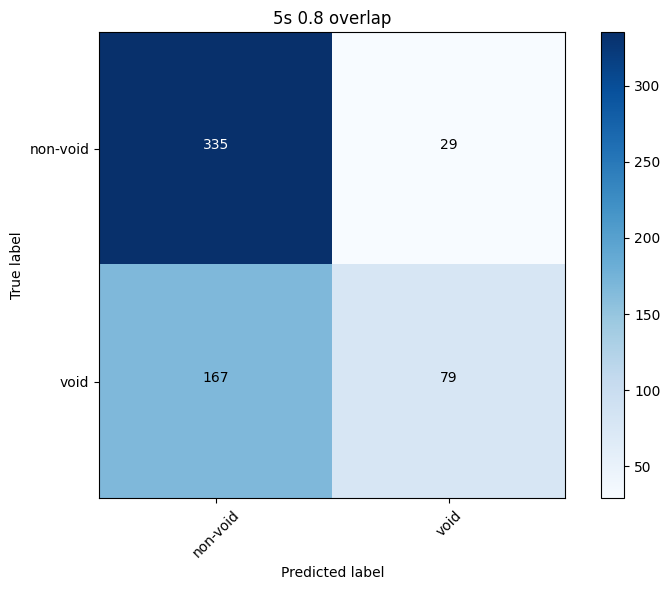

In [11]:
# 4. Generate Metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\n=== Key Metrics ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (macro avg): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro avg): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score (macro avg): {f1_score(y_test, y_pred, average='macro'):.4f}")

# 5. Confusion Matrix Visualization
def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("5s 0.8 overlap")
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred, classes=le.classes_)

In [ ]:
# label_encoder = LabelEncoder()
# # Encode y_test and y_train
# y_train_encoded = label_encoder.fit_transform(y_train)
# y_test_encoded = label_encoder.transform(y_test)

In [ ]:
# from sklearn.metrics import accuracy_score, f1_score

# # Predict on training data (caution: this can be optimistic)
# y_train_pred = classifier.predict(X_train)
# y_test_pred = classifier.predict(X_test)
# # Calculate metrics
# train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
# test_accuracy = accuracy_score(y_test_encoded, y_test_pred)

# train_f1 = f1_score(y_train_encoded, y_train_pred, average='macro')
# test_f1 = f1_score(y_test_encoded, y_test_pred, average='macro')

# print(f"Train Accuracy: {train_accuracy:.4f} | Test Accuracy: {test_accuracy:.4f}")
# print(f"Train F1-Score: {train_f1:.4f} | Test F1-Score: {test_f1:.4f}")

# # Check for overfitting
# if train_accuracy > test_accuracy + 0.15:  # Threshold can be adjusted
#     print("⚠️ Warning: Model may be overfitting (large gap between train and test performance)")
# else:
#     print("✅ No significant overfitting detected")

In [ ]:
# from tabpfn import TabPFNClassifier
# import numpy as np

# # Assuming X_train, X_test, y_train, y_test are your features and targets
# # TabPFN works best with <1000 training samples

# # Initialize the classifier
# classifier = TabPFNClassifier(device='cuda' if torch.cuda.is_available() else 'cpu', N_ensemble_configurations=32)

# # Fit the model (this is very fast)
# classifier.fit(X_train, y_train_encoded)

# # Predict
# y_pred_encoded = classifier.predict(X_test)
# y_pred_proba = classifier.predict_proba(X_test)

# y_pred = label_encoder.inverse_transform(y_pred_encoded)  # Convert back to ["high", "low"]